Federated CNN MODEL USING Adagrad OPTIMIZER WITH MOMENTUM=0.9

In [1]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try: # allow memory growth
        for g in gpus:
            tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("GPU config error:", e)


2025-11-01 08:12:38.302567: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
import os
import time
import csv
import json
import gc
from datetime import datetime

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.python.framework.errors_impl import ResourceExhaustedError

from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

In [4]:
# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

In [5]:
# Ensure logs and models dirs
os.makedirs("sdg-logs", exist_ok=True)
os.makedirs("sdg-models", exist_ok=True)
os.makedirs("tmp_models", exist_ok=True)

In [6]:
# -------------------------
# Timing callback
# -------------------------
class TimingCallback(Callback):
    def __init__(self, fold_no, client_id, epoch_time_records):
        super().__init__()
        self.fold_no = fold_no
        self.client_id = client_id
        self.epoch_times = []
        self.epoch_time_records = epoch_time_records

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        t = time.time() - self._epoch_start
        self.epoch_times.append(t)
        try:
            lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        except Exception:
            lr = None
        train_acc = logs.get('accuracy')
        val_acc = logs.get('val_accuracy')
        train_loss = logs.get('loss')
        val_loss = logs.get('val_loss')
        # record: fold, client, epoch, time, train_acc, val_acc, train_loss, val_loss, lr
        self.epoch_time_records.append([self.fold_no, self.client_id, epoch + 1, t, train_acc, val_acc, train_loss, val_loss, lr])
        print(f"⏱️ [Fold {self.fold_no} Client {self.client_id}] Epoch {epoch+1} time: {t:.2f}s | train_acc={train_acc:.4f} val_acc={val_acc}")

In [7]:
# -------------------------
# ClientSequence: on-the-fly loading
# -------------------------
class ClientSequence(keras.utils.Sequence):
    def __init__(self, filepaths, labels, img_size=(64, 64), batch_size=16, num_classes=4, shuffle=True):
        self.filepaths = np.array(filepaths)
        self.labels = np.array(labels)
        self.img_size = img_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / float(self.batch_size)))

    def __getitem__(self, index):
        batch_idx = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_files = self.filepaths[batch_idx]
        batch_labels = self.labels[batch_idx]
        X = np.zeros((len(batch_files), *self.img_size, 3), dtype=np.float32)
        y = np.zeros((len(batch_files), self.num_classes), dtype=np.float32)
        for i, fp in enumerate(batch_files):
            img = cv2.imread(fp)
            if img is None:
                img = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.img_size)
            img = img.astype(np.float32) / 255.0
            y[i, int(batch_labels[i])] = 1.0
            X[i] = img
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [8]:
# -------------------------
# Federated class
# -------------------------
class FederatedBrainTumorCNN:
    def __init__(self, num_clients=5, img_size=(64, 64), num_classes=4, class_names=None):
        self.num_clients = num_clients
        self.img_size = img_size
        self.num_classes = num_classes
        self.class_names = class_names or ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.global_model = None
        self.history = {'val_accuracy': [], 'val_loss': []}

    def create_cnn_model(self):
        model = models.Sequential([
            layers.Input(shape=(*self.img_size, 3)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
            layers.BatchNormalization(),
            layers.MaxPooling2D((2, 2)),
            layers.Dropout(0.25),

            layers.Flatten(),
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])


        model.compile(
            optimizer=keras.optimizers.Adagrad(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        return model

    def load_data_generators(self, train_dir, test_dir, batch_size=16):
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            width_shift_range=0.2,
            height_shift_range=0.2,
            horizontal_flip=True,
            zoom_range=0.2,
            fill_mode='nearest',
            validation_split=0.2
        )
        test_datagen = ImageDataGenerator(rescale=1./255)

        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            subset='training',
            shuffle=True
        )

        val_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            subset='validation',
            shuffle=False
        )

        test_generator = test_datagen.flow_from_directory(
            test_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        idx_to_class = {v: k for k, v in train_generator.class_indices.items()}
        self.class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
        return train_generator, val_generator, test_generator

    def split_filepaths_for_clients(self, train_generator):
        filepaths = np.array(train_generator.filepaths)
        labels = np.array(train_generator.classes, dtype=int)
        indices = np.arange(len(filepaths))
        np.random.shuffle(indices)
        splits = np.array_split(indices, self.num_clients)
        client_filelists = []
        for s in splits:
            client_filelists.append((filepaths[s].tolist(), labels[s].tolist()))
        return client_filelists

    def federated_averaging(self, client_weights):
        avg_weights = []
        for weights_tuple in zip(*client_weights):
            avg_weights.append(np.mean(weights_tuple, axis=0))
        return avg_weights

    # -------------------------
    # Federated training (with timing, comm bytes, logs)
    # -------------------------
    def train_federated(self, train_dir, val_generator, num_rounds=5, local_epochs=6, batch_size=16, start_round=1):
        print("\n========== FEDERATED TRAINING STARTED ==========")
        print(f"Clients: {self.num_clients}, Rounds: {num_rounds}, Local epochs: {local_epochs}, Batch size: {batch_size}")

        # ensure global model initialized
        if self.global_model is None:
            if start_round > 1:
                raise ValueError("Load checkpoint into self.global_model before resuming.")
            self.global_model = self.create_cnn_model()

        base_datagen = ImageDataGenerator(rescale=1./255)
        base_gen = base_datagen.flow_from_directory(train_dir, target_size=self.img_size, batch_size=batch_size,
                                                    class_mode='categorical', shuffle=False)
        client_filelists = self.split_filepaths_for_clients(base_gen)

        # Prepare logging CSVs
        epoch_time_records = []  # rows: [round, client_id, epoch, time_sec, train_acc, val_acc, train_loss, val_loss, lr]
        comm_records = []        # rows: [round, client_id, bytes_sent_server_to_client, bytes_returned_client_to_server]
        round_summary_rows = []  # rows: [round, total_comm_bytes, round_time_sec, val_loss, val_acc]

        # history keys
        if not hasattr(self, 'history') or not isinstance(self.history, dict):
            self.history = {'val_accuracy': [], 'val_loss': []}

        for round_num in range(start_round - 1, num_rounds):
            print(f"\n========== ROUND {round_num + 1}/{num_rounds} ==========")
            round_start_time = time.time()
            client_weights = []
            total_comm_this_round = 0
            per_client_times = []

            for client_id, (filepaths, labels) in enumerate(client_filelists):
                print(f"  -> Client {client_id + 1}/{self.num_clients} | samples: {len(filepaths)}")
                # server -> client: size of current global model weights
                server_weights = self.global_model.get_weights()
                bytes_server_to_client = sum([w.nbytes for w in server_weights])
                # record server->client comm (simulating send)
                # NOTE: in many FL systems server sends only updated params; here we record full weights for clarity
                print(f"    bytes server->client: {bytes_server_to_client:,} bytes")

                # create client model and load global weights
                client_model = self.create_cnn_model()
                client_model.set_weights(self.global_model.get_weights())

                # create sequence loader for client
                seq = ClientSequence(filepaths, labels, img_size=self.img_size, batch_size=batch_size,
                                     num_classes=self.num_classes, shuffle=True)

                # timing callback per client to get per-epoch times
                timing_cb = TimingCallback(round_num + 1, client_id + 1, epoch_time_records)
                callbacks = [
                    timing_cb,
                    EarlyStopping(patience=3, restore_best_weights=True, verbose=0, monitor='loss'),
                    ReduceLROnPlateau(factor=0.5, patience=2, verbose=0, monitor='loss')
                ]

                client_start_time = time.time()
                try:
                    client_model.fit(seq, epochs=local_epochs, verbose=1, callbacks=callbacks)
                except ResourceExhaustedError as oom:
                    print("!! OOM during client training:", oom)
                    # attempt to save and reduce batch/size then retry (omitted here for brevity)
                    raise
                client_time = time.time() - client_start_time
                per_client_times.append(client_time)
                print(f"    client {client_id+1} training time: {client_time:.2f}s")

                # client -> server: size of client weights returned
                client_w = client_model.get_weights()
                bytes_client_to_server = sum([w.nbytes for w in client_w])
                print(f"    bytes client->server: {bytes_client_to_server:,} bytes")

                # append communication record
                comm_records.append([round_num + 1, client_id + 1, bytes_server_to_client, bytes_client_to_server])
                total_comm_this_round += (bytes_server_to_client + bytes_client_to_server)

                # append client weights for FedAvg
                client_weights.append(client_w)

                # cleanup client model to free memory
                try:
                    del client_model
                except Exception:
                    pass
                gc.collect()

            # Federated averaging
            print("Aggregating client weights (FedAvg)...")
            averaged_weights = []
            for layer_weights in zip(*client_weights):
                stacked = np.stack(layer_weights, axis=0)
                averaged = np.mean(stacked, axis=0)
                averaged_weights.append(averaged)

            self.global_model.set_weights(averaged_weights)

            # Evaluate global model on validation set
            print("Evaluating global model on validation set...")
            val_loss, val_accuracy = self.global_model.evaluate(val_generator, verbose=1)
            print(f"[Round {round_num + 1}] Val loss: {val_loss:.4f} | Val accuracy: {val_accuracy:.4f}")

            if len(self.history['val_loss']) < (round_num + 1):
                self.history['val_loss'].append(float(val_loss))
                self.history['val_accuracy'].append(float(val_accuracy))

            # Save checkpoint after each round
            ckpt_path = os.path.join("sdg-models", f"federated_model_round_{round_num + 1}.keras")
            try:
                self.global_model.save(ckpt_path)
                print(f"[✓] Saved checkpoint: {ckpt_path}")
            except Exception as e:
                print("Warning: failed to save checkpoint:", e)

            round_time = time.time() - round_start_time
            round_summary_rows.append([round_num + 1, total_comm_this_round, round_time, float(val_loss), float(val_accuracy)])
            # lightweight cleanup
            gc.collect()

        # --- Save logs to CSVs ---
        # epoch timing
        epoch_csv = os.path.join("sdg-logs", "federated_epoch_times.csv")
        with open(epoch_csv, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["Round", "Client", "Epoch", "TimeSec", "TrainAcc", "ValAcc", "TrainLoss", "ValLoss", "LR"])
            writer.writerows(epoch_time_records)
        print(f"[LOG] Saved epoch timing to: {epoch_csv}")

        # communication bytes per client/round
        comm_csv = os.path.join("sdg-logs", "comm_bytes_per_round.csv")
        with open(comm_csv, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["Round", "Client", "Bytes_Server_to_Client", "Bytes_Client_to_Server"])
            writer.writerows(comm_records)
        print(f"[LOG] Saved communication bytes to: {comm_csv}")

        # round summary
        round_csv = os.path.join("sdg-logs", "federated_training_log.csv")
        with open(round_csv, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["Round", "Total_Comm_Bytes", "RoundTimeSec", "ValLoss", "ValAcc"])
            writer.writerows(round_summary_rows)
        print(f"[LOG] Saved round summary to: {round_csv}")

        print("\n========== FEDERATED TRAINING COMPLETED ==========")
        return self.global_model

    # -------------------------
    # K-fold cross validation (saves models per fold)
    # -------------------------
    def kfold_cross_validation(self, train_dir, k_folds=5, batch_size=16):
        print("\n" + "="*70)
        print("K-FOLD CROSS-VALIDATION")
        print("="*70)

        datagen = ImageDataGenerator(rescale=1./255)
        full_generator = datagen.flow_from_directory(
            train_dir,
            target_size=self.img_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=False
        )

        filepaths = np.array(full_generator.filepaths)
        labels = np.array(full_generator.classes, dtype=int)
        x_dummy = np.arange(len(filepaths))
        kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(kfold.split(x_dummy)):
            print(f"\n-- Fold {fold + 1}/{k_folds} --")
            train_files = filepaths[train_idx]
            train_labels = labels[train_idx]
            val_files = filepaths[val_idx]
            val_labels = labels[val_idx]

            train_seq = ClientSequence(train_files, train_labels, img_size=self.img_size, batch_size=batch_size,
                                       num_classes=self.num_classes, shuffle=True)
            val_seq = ClientSequence(val_files, val_labels, img_size=self.img_size, batch_size=batch_size,
                                     num_classes=self.num_classes, shuffle=False)

            model = self.create_cnn_model()
            callbacks = [
                EarlyStopping(patience=5, restore_best_weights=True, verbose=0),
                ReduceLROnPlateau(factor=0.5, patience=3, verbose=0)
            ]

            model.fit(train_seq, validation_data=val_seq, epochs=30, verbose=1, callbacks=callbacks)
            _, accuracy = model.evaluate(val_seq, verbose=0)
            fold_scores.append(float(accuracy))
            print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")

            # Save fold model
            fold_model_path = os.path.join("sdg-models", f"kfold_model_fold{fold+1}.keras")
            try:
                model.save(fold_model_path)
                print(f"[✓] Saved K-Fold model: {fold_model_path}")
            except Exception as e:
                print("Warning: could not save k-fold model:", e)

            # cleanup
            try:
                del model
            except Exception:
                pass
            tf.keras.backend.clear_session()
            gc.collect()

        # Save fold results CSV
        kfold_csv = os.path.join("sdg-logs", "kfold_results.csv")
        with open(kfold_csv, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["Fold", "Accuracy"])
            for i, acc in enumerate(fold_scores, start=1):
                writer.writerow([i, acc])
        print(f"[LOG] Saved k-fold results to: {kfold_csv}")

        print(f"\nK-Fold Cross-Validation Mean Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
        return fold_scores

    # -------------------------
    # Evaluation and plotting
    # -------------------------
    def evaluate_model(self, test_generator):
        print("\n" + "="*70)
        print("MODEL EVALUATION ON TEST SET")
        print("="*70)

        y_pred_probs = self.global_model.predict(test_generator, verbose=1)
        y_pred = np.argmax(y_pred_probs, axis=1)
        y_true = test_generator.classes

        accuracy = accuracy_score(y_true, y_pred)
        print(f"Test Accuracy: {accuracy:.4f}")

        report = classification_report(y_true, y_pred, target_names=self.class_names, digits=4)
        print(report)
        # save classification report
        with open(os.path.join("logs", "classification_report.txt"), "w") as f:
            f.write(report)

        cm = confusion_matrix(y_true, y_pred)
        return y_true, y_pred, y_pred_probs, cm, accuracy

    def plot_training_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(self.history['val_accuracy'], marker='o', linewidth=2)
        axes[0].set_title('Federated Learning - Validation Accuracy')
        axes[0].set_xlabel('Federated Round')
        axes[0].set_ylabel('Accuracy')
        axes[0].grid(True)
        axes[0].set_ylim([0, 1])

        axes[1].plot(self.history['val_loss'], marker='o', linewidth=2)
        axes[1].set_title('Federated Learning - Validation Loss')
        axes[1].set_xlabel('Federated Round')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True)

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: training_history.png")

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(9, 7))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: confusion_matrix.png")

    def plot_performance_metrics(self, y_true, y_pred):
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
        x = np.arange(len(self.class_names))
        width = 0.25
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(x - width, precision, width, label='Precision')
        ax.bar(x, recall, width, label='Recall')
        ax.bar(x + width, f1, width, label='F1')
        ax.set_xticks(x)
        ax.set_xticklabels(self.class_names, rotation=45)
        ax.set_ylim([0, 1.05])
        ax.legend()
        plt.tight_layout()
        plt.savefig('performance_metrics.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved: performance_metrics.png")

    def save_results(self, fold_scores, test_accuracy):
        results = {
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'model_config': {'num_clients': self.num_clients, 'image_size': self.img_size, 'num_classes': self.num_classes},
            'kfold_results': {'fold_scores': [float(s) for s in fold_scores], 'mean_accuracy': float(np.mean(fold_scores)),
                              'std_accuracy': float(np.std(fold_scores))},
            'test_accuracy': float(test_accuracy),
            'training_history': {'val_accuracy': [float(x) for x in self.history['val_accuracy']],
                                 'val_loss': [float(x) for x in self.history['val_loss']]}
        }
        with open('federated_learning_results.json', 'w') as f:
            json.dump(results, f, indent=4)
        print("Saved: federated_learning_results.json")

In [9]:
# -------------------------
# main runner (example usage)
# -------------------------
def main():
    TRAIN_DIR = 'Brain_Tumor_data/Training'
    TEST_DIR = 'Brain_Tumor_data/Testing'

    NUM_CLIENTS = 5
    NUM_FEDERATED_ROUNDS = 5
    LOCAL_EPOCHS = 6
    K_FOLDS = 5
    BATCH_SIZE = 16

    print("CONFIG:")
    print(f"  clients: {NUM_CLIENTS}, fed rounds: {NUM_FEDERATED_ROUNDS}, local epochs: {LOCAL_EPOCHS}, kfolds: {K_FOLDS}, batch_size: {BATCH_SIZE}")

    fed = FederatedBrainTumorCNN(num_clients=NUM_CLIENTS, img_size=(64, 64))
    train_gen, val_gen, test_gen = fed.load_data_generators(TRAIN_DIR, TEST_DIR, batch_size=BATCH_SIZE)
    print("Samples:", train_gen.samples, "Validation:", val_gen.samples, "Test:", test_gen.samples)

    # K-fold (optional)
    fold_scores = fed.kfold_cross_validation(TRAIN_DIR, k_folds=K_FOLDS, batch_size=BATCH_SIZE)

    # Federated training
    global_model = fed.train_federated(TRAIN_DIR, val_gen, num_rounds=NUM_FEDERATED_ROUNDS,
                                       local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE)

    fed.plot_training_history()

    # Evaluate
    y_true, y_pred, y_pred_probs, cm, test_acc = fed.evaluate_model(test_gen)
    fed.plot_confusion_matrix(cm)
    fed.plot_performance_metrics(y_true, y_pred)
    fed.save_results(fold_scores, test_acc)

    # Save final models
    try:
        global_model.save('federated_brain_tumor_model.h5')
        print("Saved model: federated_brain_tumor_model.h5")
        global_model.save('federated_brain_tumor_model.keras')
        print("Saved model: federated_brain_tumor_model.keras")
    except Exception as e:
        print("Warning: could not save final model:", e)

CONFIG:
  clients: 5, fed rounds: 5, local epochs: 6, kfolds: 5, batch_size: 16
Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Samples: 4571 Validation: 1141 Test: 1311

K-FOLD CROSS-VALIDATION
Found 5712 images belonging to 4 classes.

-- Fold 1/5 --


I0000 00:00:1761984870.289202     842 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1767 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6
/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


2025-11-01 08:14:35.908432: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f86700034d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-01 08:14:35.908464: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2025-11-01 08:14:36.228063: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-01 08:14:36.915916: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91300


  2/286 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.3750 - loss: 1.9719   

I0000 00:00:1761984889.960850    1626 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


286/286 ━━━━━━━━━━━━━━━━━━━━ 59s 150ms/step - accuracy: 0.6246 - loss: 1.0783 - val_accuracy: 0.4471 - val_loss: 3.0550 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step - accuracy: 0.6977 - loss: 0.8593 - val_accuracy: 0.6325 - val_loss: 1.4401 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - accuracy: 0.7352 - loss: 0.7322 - val_accuracy: 0.7200 - val_loss: 1.0398 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.7455 - loss: 0.7073 - val_accuracy: 0.7638 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 27s 95ms/step - accuracy: 0.7603 - loss: 0.6770 - val_accuracy: 0.7690 - val_loss: 0.6704 - learning_rate: 0.0010
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 27s 95ms/step - accuracy: 0.7669 - loss: 0.6495 - val_accuracy: 0.7568 - val_loss: 0.7009 - learning_rate: 0.0010
Epoch 7/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 28s 97ms/step - accuracy: 0.7783 - loss: 0.62

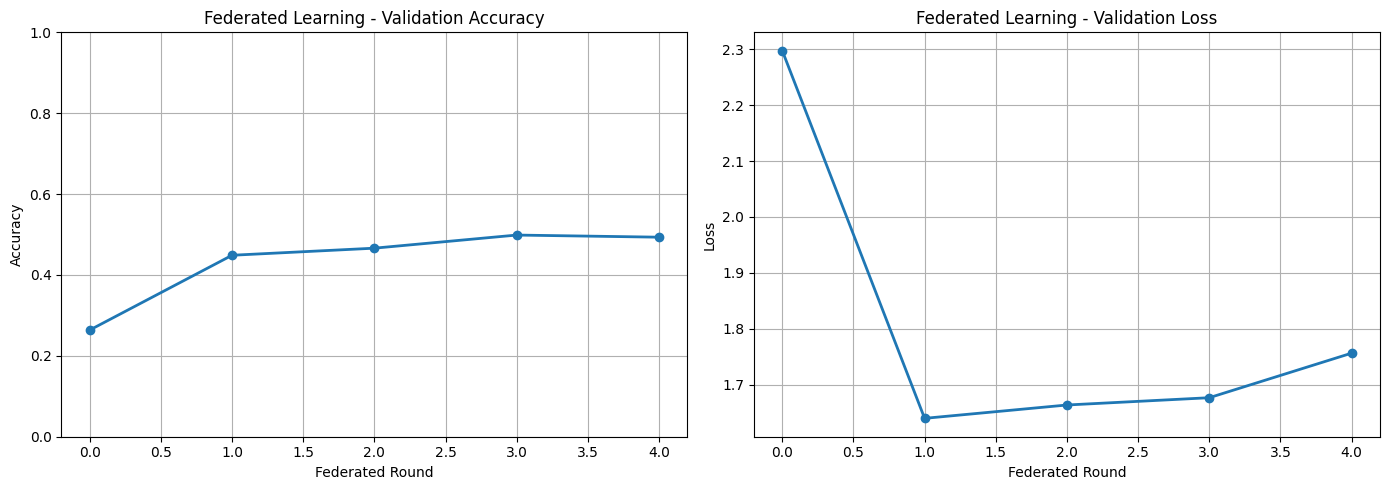

Saved: training_history.png

MODEL EVALUATION ON TEST SET
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step
Test Accuracy: 0.7162
              precision    recall  f1-score   support

      glioma     0.6762    0.8700    0.7609       300
  meningioma     0.7949    0.1013    0.1797       306
     notumor     0.9067    0.8642    0.8850       405
   pituitary     0.5940    0.9900    0.7425       300

    accuracy                         0.7162      1311
   macro avg     0.7429    0.7064    0.6420      1311
weighted avg     0.7563    0.7162    0.6594      1311



FileNotFoundError: [Errno 2] No such file or directory: 'logs/classification_report.txt'

In [10]:
if __name__ == "__main__":
    main()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import FuncFormatter

sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
epoch_df = pd.read_csv("sdg-logs/federated_epoch_times.csv")
round_df = pd.read_csv("sdg-logs/federated_training_log.csv")
comm_df = pd.read_csv("sdg-logs/comm_bytes_per_round.csv")

print("Epoch Data:", epoch_df.shape)
print("Round Data:", round_df.shape)
print("Comm Data:", comm_df.shape)


Epoch Data: (149, 9)
Round Data: (5, 5)
Comm Data: (25, 4)


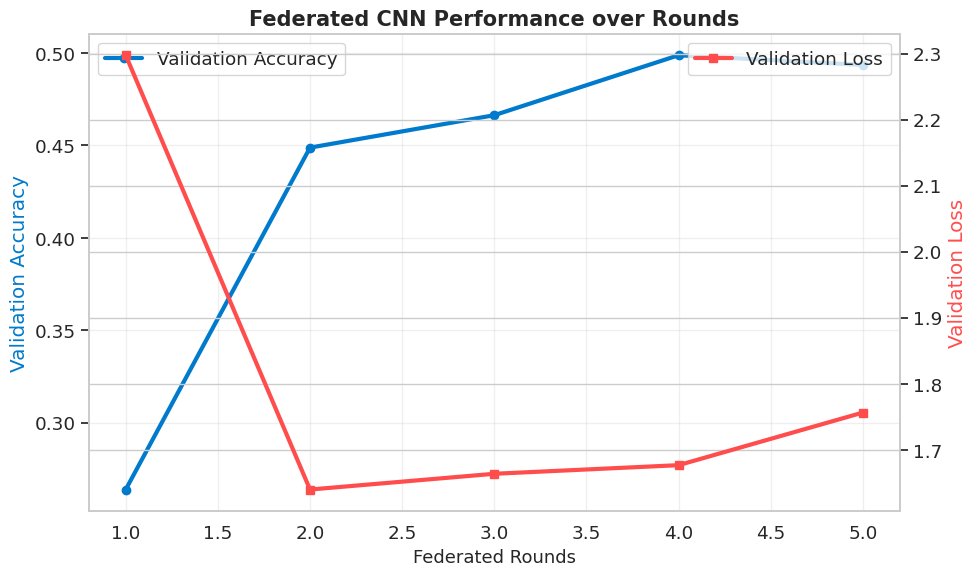

In [3]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.plot(round_df['Round'], round_df['ValAcc'], color='#007acc', marker='o', lw=3, label='Validation Accuracy')
ax2 = ax1.twinx()
ax2.plot(round_df['Round'], round_df['ValLoss'], color='#ff4d4d', marker='s', lw=3, label='Validation Loss')

ax1.set_xlabel("Federated Rounds", fontsize=13)
ax1.set_ylabel("Validation Accuracy", color='#007acc')
ax2.set_ylabel("Validation Loss", color='#ff4d4d')
ax1.set_title("Federated CNN Performance over Rounds", fontsize=15, weight='bold')

ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_24351/2944798485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Client', y='TimeSec', data=avg_epoch_time, palette='coolwarm')


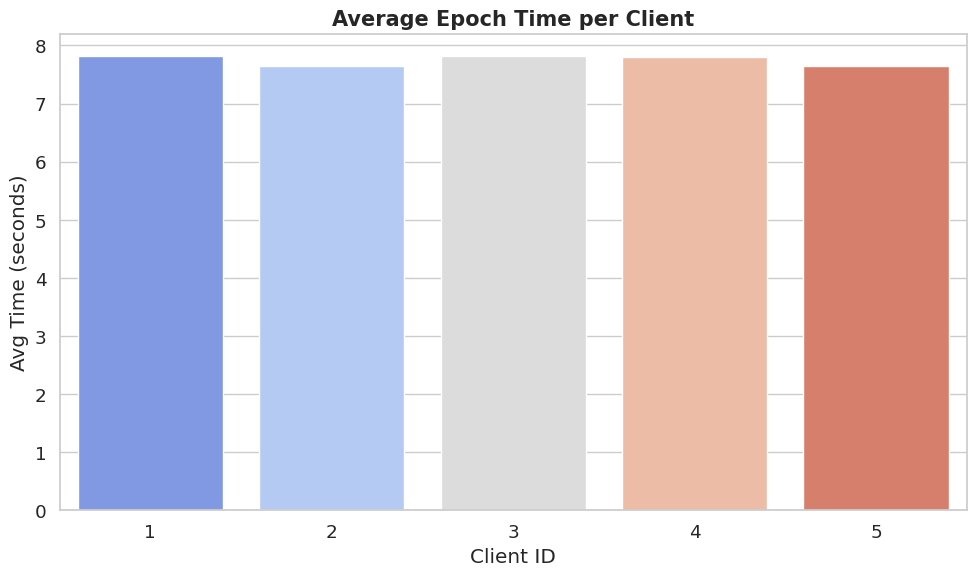

In [4]:
avg_epoch_time = epoch_df.groupby(['Client'])['TimeSec'].mean().reset_index()
sns.barplot(x='Client', y='TimeSec', data=avg_epoch_time, palette='coolwarm')
plt.title("Average Epoch Time per Client", fontsize=15, weight='bold')
plt.xlabel("Client ID")
plt.ylabel("Avg Time (seconds)")
plt.tight_layout()
plt.show()


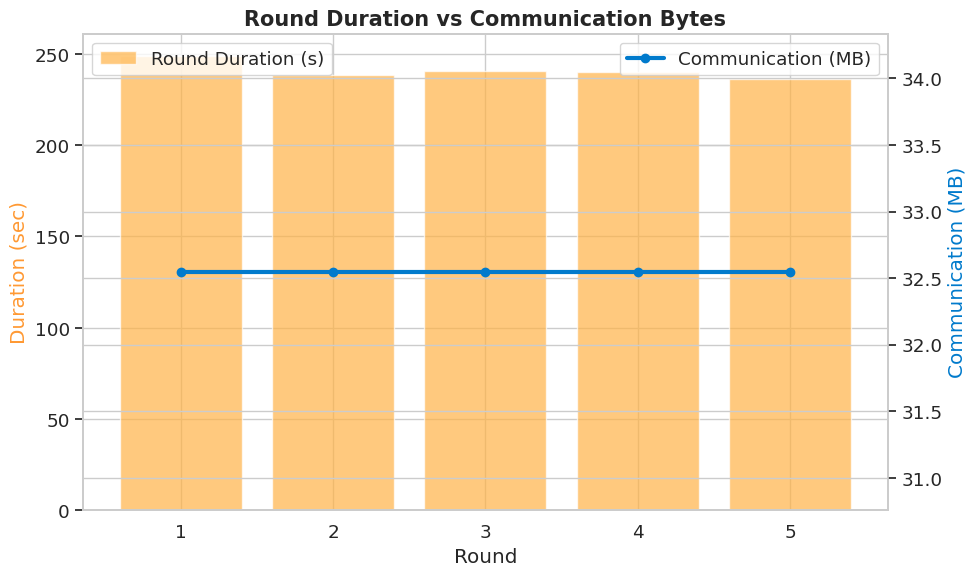

In [5]:
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.bar(round_df['Round'], round_df['RoundTimeSec'], color='#ffb347', alpha=0.7, label='Round Duration (s)')
ax2 = ax1.twinx()
ax2.plot(round_df['Round'], round_df['Total_Comm_Bytes'] / 1e6, color='#007acc', marker='o', lw=3, label='Communication (MB)')

ax1.set_xlabel("Round")
ax1.set_ylabel("Duration (sec)", color='#ff9933')
ax2.set_ylabel("Communication (MB)", color='#007acc')
plt.title("Round Duration vs Communication Bytes", fontsize=15, weight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


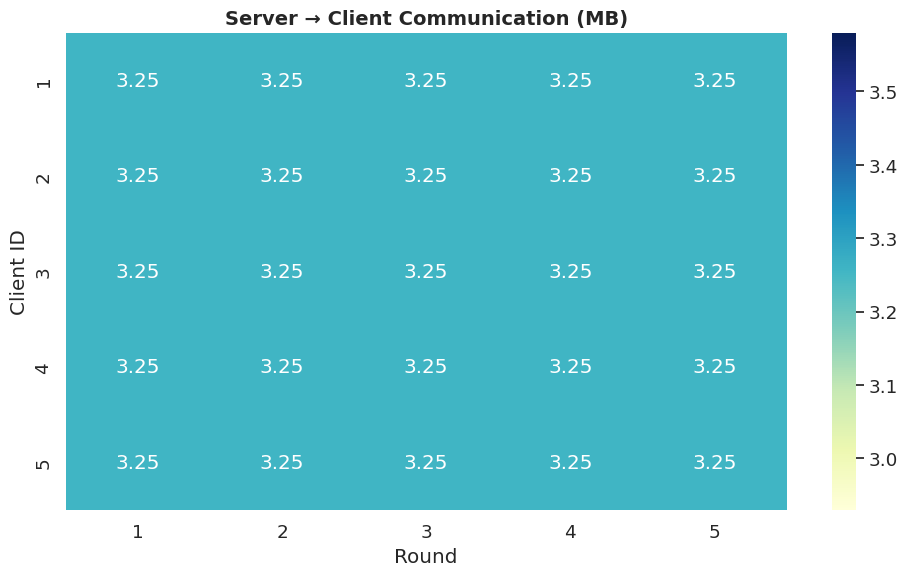

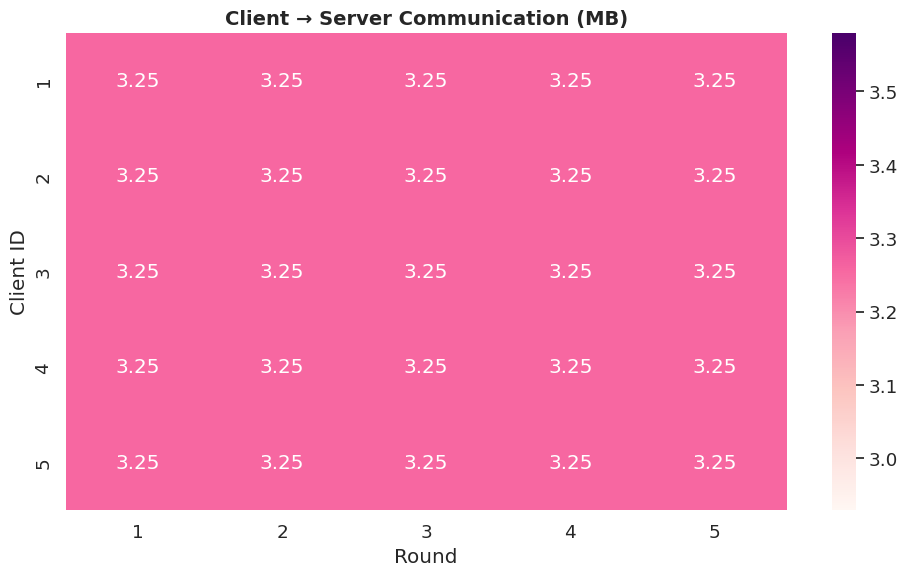

In [6]:
pivot_comm = comm_df.pivot_table(index='Client', columns='Round',
                                 values=['Bytes_Server_to_Client','Bytes_Client_to_Server'], aggfunc='sum')
sns.heatmap(pivot_comm['Bytes_Server_to_Client'] / 1e6, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("Server → Client Communication (MB)", fontsize=14, weight='bold')
plt.ylabel("Client ID")
plt.xlabel("Round")
plt.tight_layout()
plt.show()

sns.heatmap(pivot_comm['Bytes_Client_to_Server'] / 1e6, cmap='RdPu', annot=True, fmt=".2f")
plt.title("Client → Server Communication (MB)", fontsize=14, weight='bold')
plt.ylabel("Client ID")
plt.xlabel("Round")
plt.tight_layout()
plt.show()


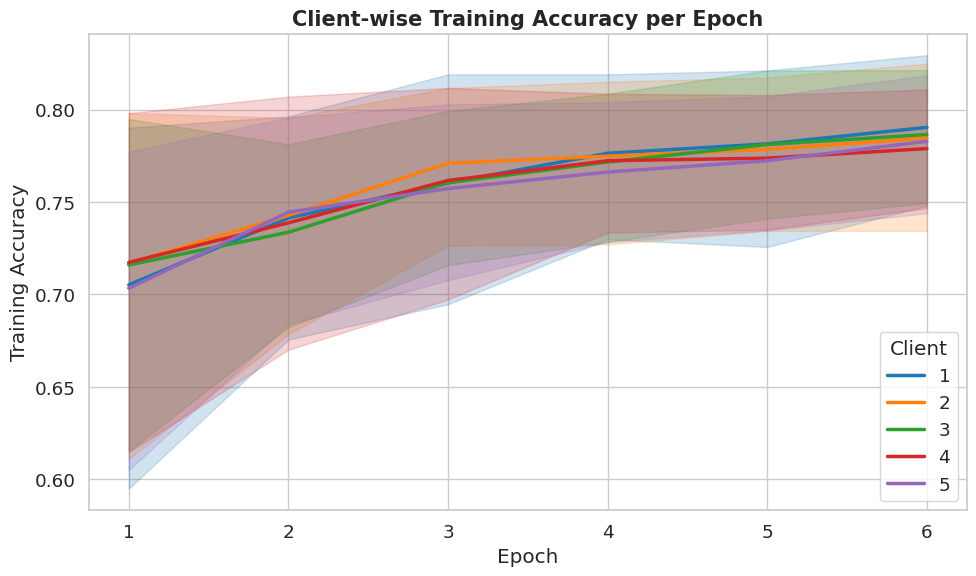

In [7]:
sns.lineplot(data=epoch_df, x='Epoch', y='TrainAcc', hue='Client', palette='tab10', lw=2.5)
plt.title("Client-wise Training Accuracy per Epoch", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.tight_layout()
plt.show()


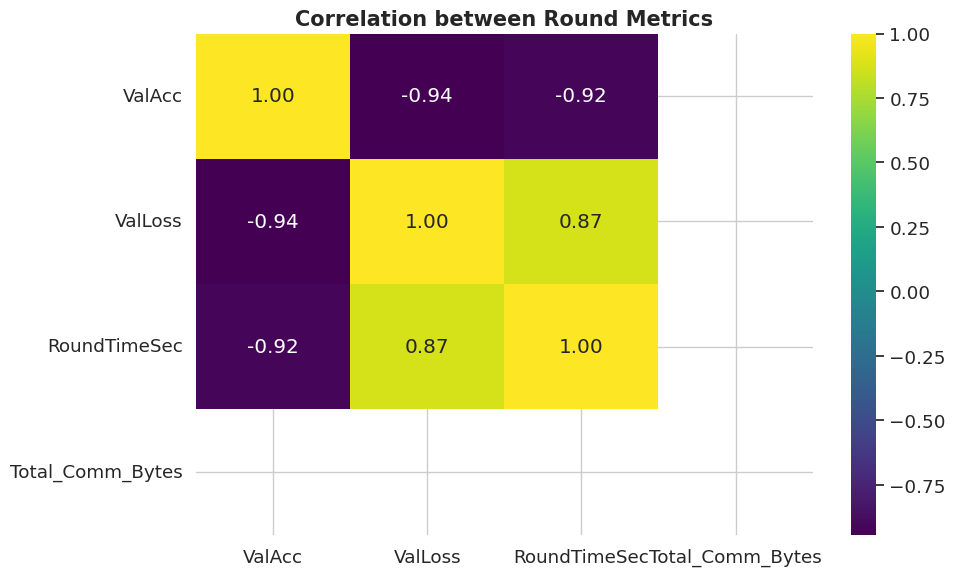

In [8]:
corr = round_df[['ValAcc', 'ValLoss', 'RoundTimeSec', 'Total_Comm_Bytes']].corr()
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f", cbar=True)
plt.title("Correlation between Round Metrics", fontsize=15, weight='bold')
plt.tight_layout()
plt.show()


In [9]:
fig = px.scatter_3d(round_df, x='Round', y='ValAcc', z='RoundTimeSec',
                    size='Total_Comm_Bytes', color='ValLoss',
                    color_continuous_scale='plasma',
                    title="Federated Learning: Accuracy vs Time vs Communication",
                    labels={'ValAcc':'Validation Accuracy', 'RoundTimeSec':'Time (s)', 'Total_Comm_Bytes':'Comm Bytes'})
fig.update_traces(marker=dict(opacity=0.8, line=dict(width=1)))
fig.show()


In [10]:
import os
os.makedirs("visuals", exist_ok=True)
for i, f in enumerate(plt.get_fignums(), 1):
    plt.figure(f)
    plt.savefig(f"visuals/figure_{i}.png", dpi=300, bbox_inches='tight')
print("✅ All figures saved in /visuals folder.")


✅ All figures saved in /visuals folder.


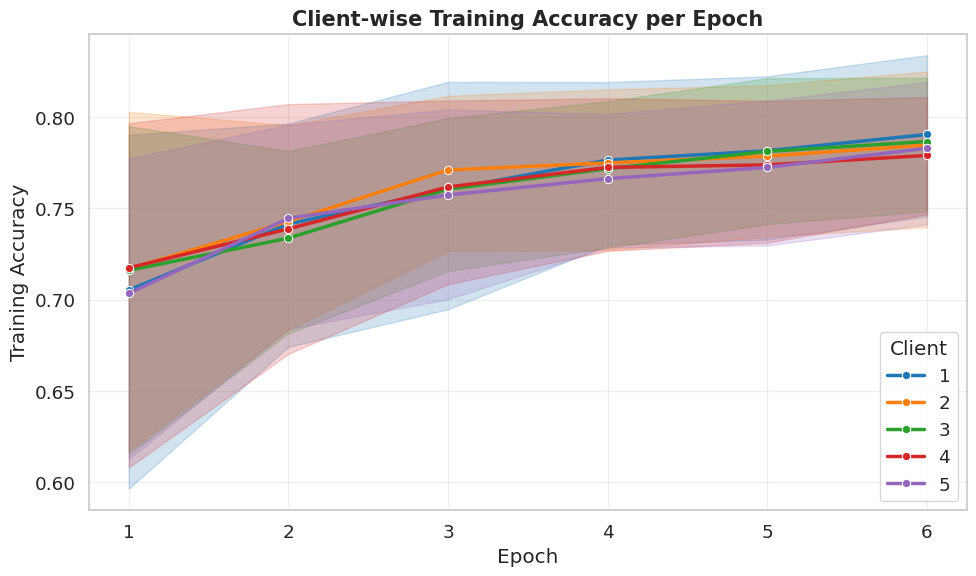

In [11]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='Epoch', y='TrainAcc', hue='Client', marker='o', lw=2.5, palette='tab10')
plt.title("Client-wise Training Accuracy per Epoch", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.legend(title='Client', loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


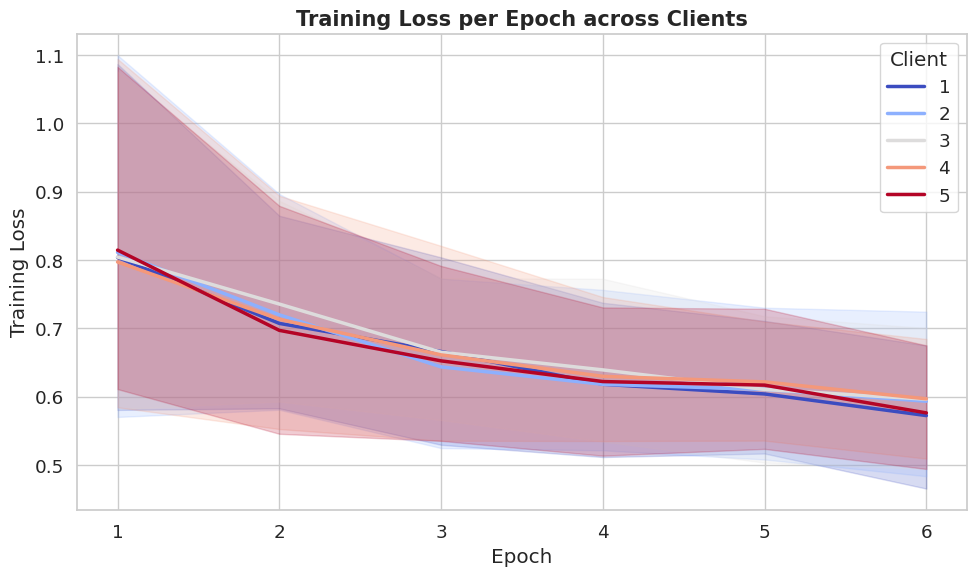

In [12]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='Epoch', y='TrainLoss', hue='Client', lw=2.5, palette='coolwarm')
plt.title("Training Loss per Epoch across Clients", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend(title='Client', loc='upper right')
plt.tight_layout()
plt.show()


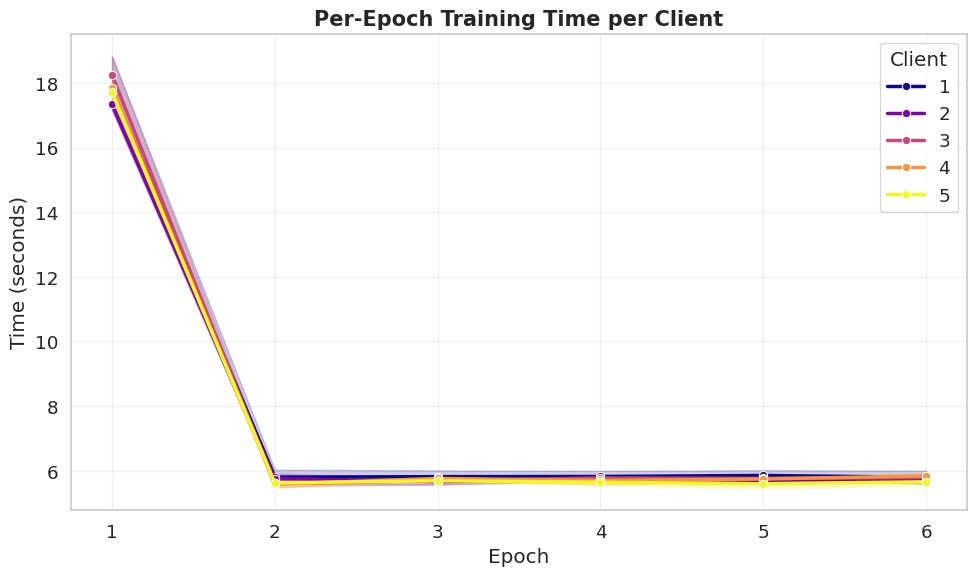

In [13]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='Epoch', y='TimeSec', hue='Client', lw=2.5, marker='o', palette='plasma')
plt.title("Per-Epoch Training Time per Client", fontsize=15, weight='bold')
plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipykernel_24351/3411560742.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




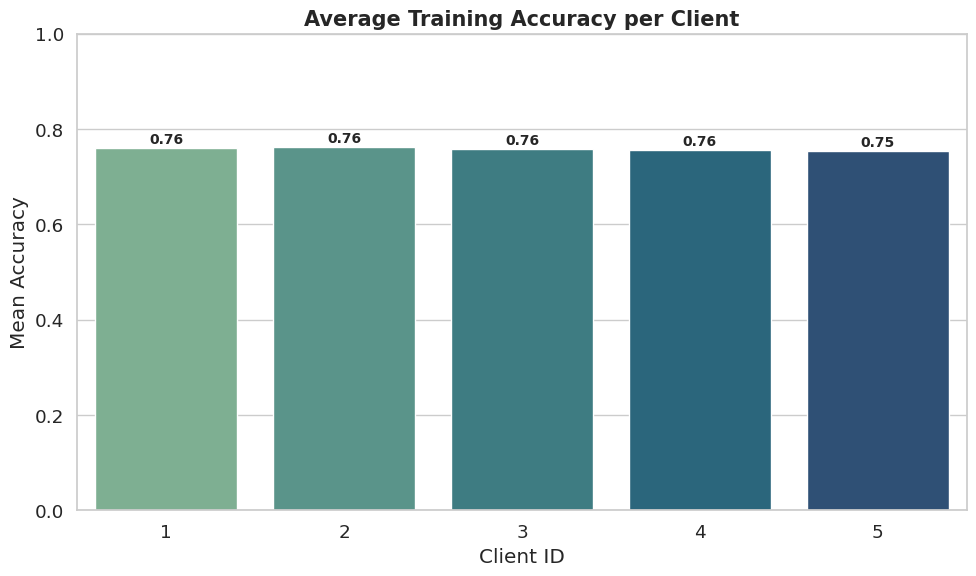

In [15]:
avg_acc = epoch_df.groupby("Client")['TrainAcc'].mean().reset_index()
sns.barplot(x="Client", y="TrainAcc", data=avg_acc, palette="crest")
plt.title("Average Training Accuracy per Client", fontsize=15, weight='bold')
plt.ylabel("Mean Accuracy")
plt.xlabel("Client ID")
for index, row in avg_acc.iterrows():
    plt.text(index, row.TrainAcc + 0.01, f"{row.TrainAcc:.2f}", ha='center', fontsize=10, weight='bold')
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()


/tmp/ipykernel_24351/3212089915.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




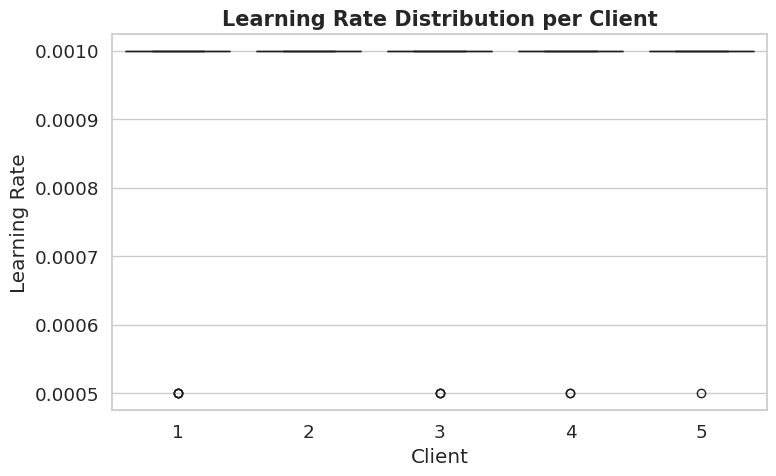

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=epoch_df, x="Client", y="LR", palette="mako")
plt.title("Learning Rate Distribution per Client", fontsize=15, weight='bold')
plt.xlabel("Client")
plt.ylabel("Learning Rate")
plt.tight_layout()
plt.show()


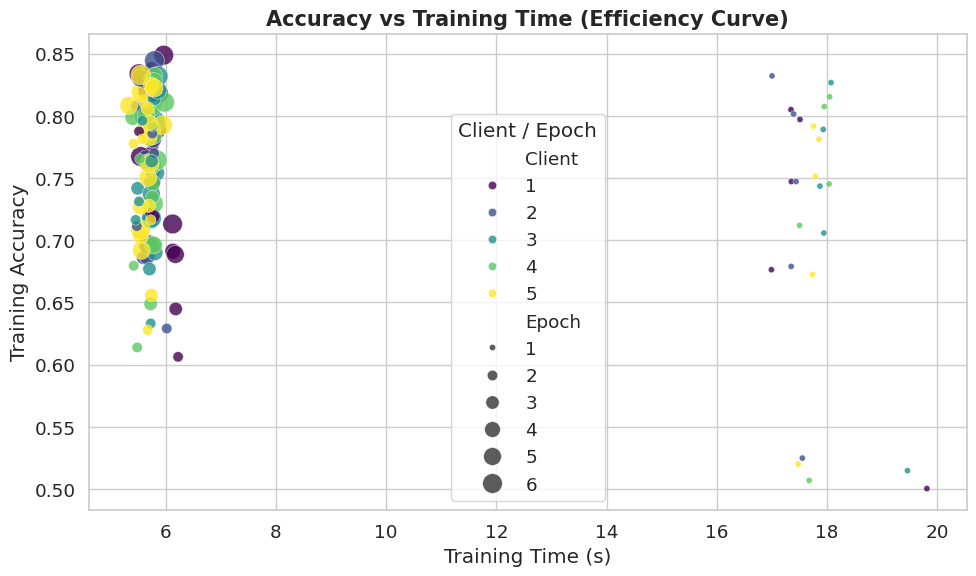

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=epoch_df, x='TimeSec', y='TrainAcc', hue='Client', size='Epoch', sizes=(20, 200), palette='viridis', alpha=0.8)
plt.title("Accuracy vs Training Time (Efficiency Curve)", fontsize=15, weight='bold')
plt.xlabel("Training Time (s)")
plt.ylabel("Training Accuracy")
plt.legend(title="Client / Epoch")
plt.tight_layout()
plt.show()


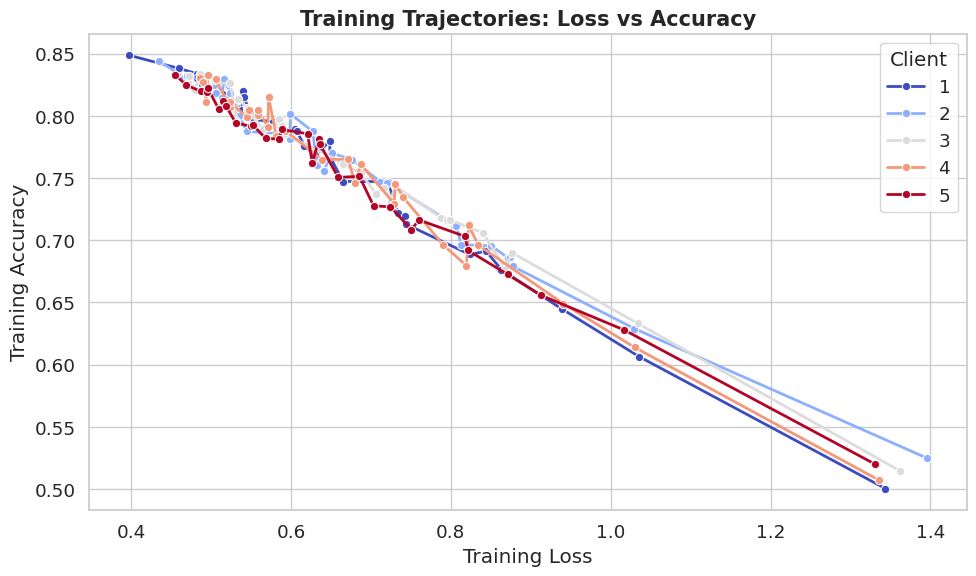

In [18]:
plt.figure(figsize=(10,6))
sns.lineplot(data=epoch_df, x='TrainLoss', y='TrainAcc', hue='Client', marker='o', lw=2, palette='coolwarm')
plt.title("Training Trajectories: Loss vs Accuracy", fontsize=15, weight='bold')
plt.xlabel("Training Loss")
plt.ylabel("Training Accuracy")
plt.tight_layout()
plt.show()


In [19]:
import plotly.graph_objects as go

client_summary = epoch_df.groupby('Client').agg({
    'TrainAcc':'mean',
    'TrainLoss':'mean',
    'TimeSec':'mean'
}).reset_index()

# normalize metrics 0-1
for col in ['TrainAcc','TrainLoss','TimeSec']:
    client_summary[col] = (client_summary[col] - client_summary[col].min()) / (client_summary[col].max() - client_summary[col].min())

categories = ['TrainAcc', 'TrainLoss', 'TimeSec']
fig = go.Figure()
for i, row in client_summary.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[categories].tolist(),
        theta=categories,
        fill='toself',
        name=f'Client {int(row.Client)}'
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title="Client Performance Radar (Normalized Metrics)"
)
fig.show()


/tmp/ipykernel_24351/697950579.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




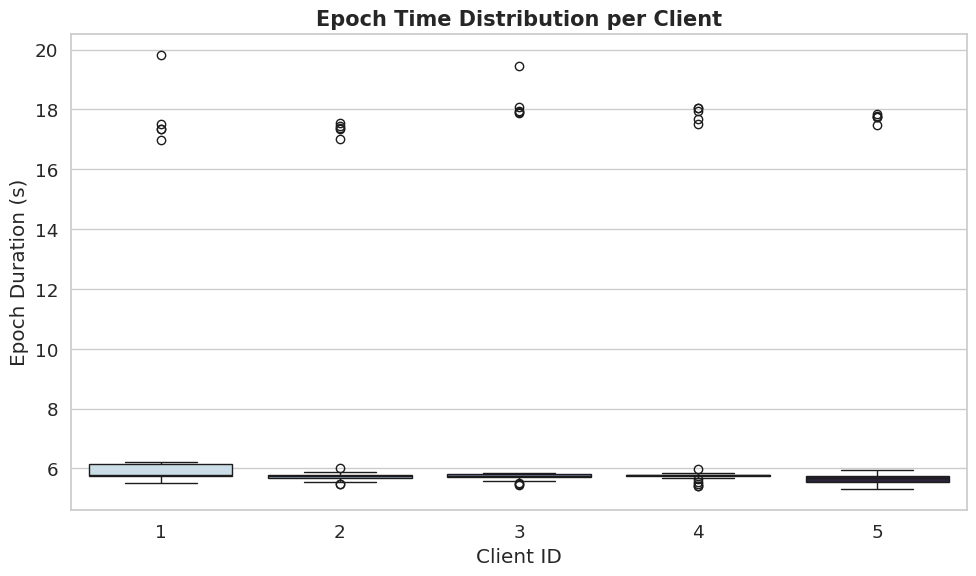

In [20]:
sns.boxplot(data=epoch_df, x='Client', y='TimeSec', palette='ch:s=.25,rot=-.25')
plt.title("Epoch Time Distribution per Client", fontsize=15, weight='bold')
plt.xlabel("Client ID")
plt.ylabel("Epoch Duration (s)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_24351/1902478155.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




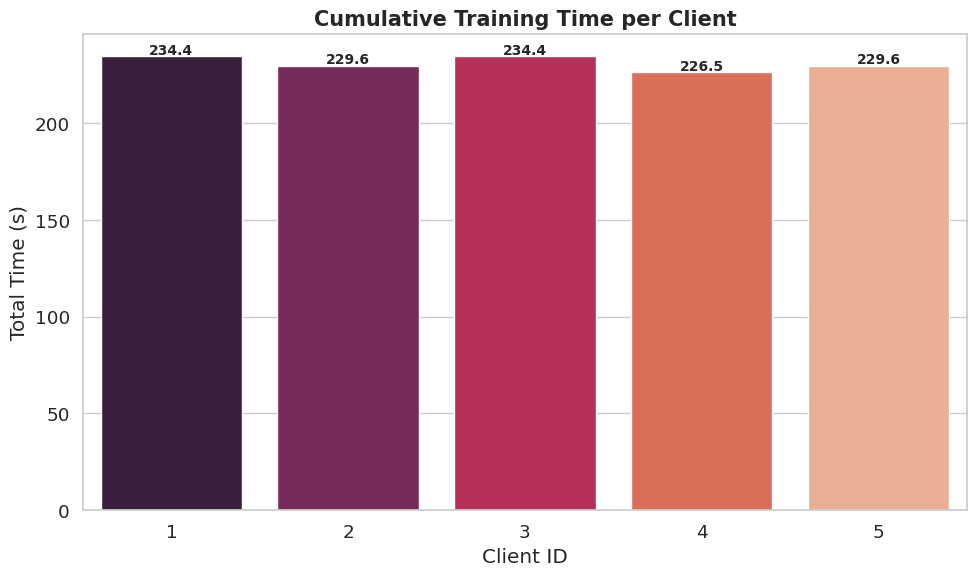

In [21]:
cum_time = epoch_df.groupby('Client')['TimeSec'].sum().reset_index()
sns.barplot(x='Client', y='TimeSec', data=cum_time, palette='rocket')
plt.title("Cumulative Training Time per Client", fontsize=15, weight='bold')
plt.xlabel("Client ID")
plt.ylabel("Total Time (s)")
for index, row in cum_time.iterrows():
    plt.text(index, row.TimeSec + 1, f"{row.TimeSec:.1f}", ha='center', fontsize=10, weight='bold')
plt.tight_layout()
plt.show()
